# 04 - Generalisation

## From selection to trust

Notebook 00 introduced the workshop frame:

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s.
$$

Notebook 03 made the selection step explicit. Once the hypothesis space, dataset, and optimization space are fixed, the machinery can return a selected rule such as $s=h_{\hat{\theta}}$.

This notebook asks the next question:

> When should the selected rule be trusted beyond the evidence that selected it?

That is the generalisation question. A selected rule can fit the observations used by the optimizer and still fail on new cases, in sparse regions, in gaps between observations, or outside the sampled range. In the language from Notebook 00, Notebook 04 asks whether the selected $s$ belongs in the acceptable solution space $\mathcal{S}$ for the use we care about.

The deployment region matters. We will use $\Omega$ for the part of input space where the rule needs to travel. A model is not equally defended everywhere just because it has one good score; it is best defended where the data, model class, and selection rule actually constrain its behaviour.

### Plain-language meaning of $\Omega$

$\Omega$ is the region where the model needs to be useful. If this were an instrument-calibration task, $\Omega$ might be the range of temperatures, concentrations, or simulation settings where future predictions will be used. A model can be defensible in one region of $\Omega$ and weak in another.

The through-line is:

1. start with the selected-rule problem left by Notebook 03;
2. separate evidence that selects parameters from evidence that checks the selected rule;
3. watch training and held-out scores diverge as $\mathcal{H}$ becomes more flexible;
4. make the train, validation, and test roles explicit;
5. inspect local support in $\Omega$, not only global error;
6. change $\mathcal{D}$ while holding $\mathcal{H}$ and $\mathcal{O}$ fixed;
7. defend a model choice as an argument about $\mathcal{H}$, $\mathcal{D}$, $\mathcal{O}$, and $\Omega$.

The controls here are ordinary variables and helper functions. Change one value, rerun the relevant cells, and ask which part of the learning frame changed.


## Learning objectives

By the end of this notebook, you should be able to:

1. distinguish evidence used for fitting from evidence used for checking;
2. explain why training performance alone cannot establish generalisation;
3. distinguish training, validation, test, and deployment roles;
4. identify local support problems such as gaps, sparse regions, and extrapolation;
5. build a defensible model-choice argument using $\mathcal{H}$, $\mathcal{D}$, $\mathcal{O}$, and the deployment region $\Omega$.


## Session arc

This notebook follows one semantic wave:

1. **Abstract:** generalisation is about performance beyond the data that selected the solution.
2. **Concrete:** split the regression data into fitting and checking evidence.
3. **Inspect:** compare fit and held-out errors across polynomial degrees.
4. **Diagnose:** identify overfitting, local support failures, gaps, and extrapolation.
5. **Intervene:** change data coverage while holding the model class and optimizer fixed.
6. **Repack:** deployment trust is an evidential argument, not a score alone.

Use this question throughout:

> Where is the selected rule supported, and where is it travelling on assumptions?


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


## Start With Selection Evidence and Checking Evidence

Notebook 03 used the same data both to score candidates and to select $\hat{\theta}$. That was the right simplification for understanding $\mathcal{O}$, but it cannot answer whether the selected rule travels.

Start with one finite dataset and split it into two roles:

- $\mathcal{D}_{fit}$ is visible to the optimizer and selects $\hat{\theta}$ for a fixed modelling choice.
- $\mathcal{D}_{check}$ is held back so we can inspect behaviour on evidence that did not select $\hat{\theta}$.

This first split is a teaching diagnostic, not a complete modelling protocol. Its job is to make the key distinction visible: the score used to choose a rule is not the same as a score measured after the rule has already been chosen.

The distinction matters because a flexible hypothesis space can specialise to the evidence that selects it. If the same rows both choose the rule and judge the rule, the judgement is partly circular: the model has already been shaped to look good there. A held-back check set asks a different question: after selection has happened, does the selected rule still make reasonable predictions on rows it did not use?

The geometry of the split matters as much as the count. A check point close to many fitting points is a test of local interpolation. A check point in a sparse gap or beyond the fitting range is a stronger probe of whether the selected rule is travelling on assumptions rather than nearby evidence.

Before looking at errors, inspect the split. Which parts of $\Omega$ are covered by fitting evidence? Where would two plausible curves have room to disagree? Which check points are asking for interpolation, and which ones are closer to extrapolation?


### Before running: separate the roles of evidence

The next cells split one finite dataset into two roles.

| Evidence role | What it is allowed to do |
|---|---|
| $\mathcal{D}_{fit}$ | Select parameters for a fixed modelling choice. |
| $\mathcal{D}_{check}$ | Check the already-selected rule on rows that did not select it. |

Before running, predict which regions will be checked strongly and which will remain weakly supported.



In [2]:
# Build a dataset and split it into evidence used for fitting and evidence held out for checking.
n_samples = 30
noise_std = 0.20
seed = 2026
sampling = "uniform"  # "uniform", "clustered", or "partial_domain"
check_size = 0.35

x_full, y_full = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)
x_train, y_train, x_test, y_test = data.train_test_split_for_workshop(
    x_full,
    y_full,
    test_size=check_size,
    seed=seed + 1,
)

print_rows(
    [
        {"split": "D_fit", "n": len(x_train), "x_min": np.min(x_train), "x_max": np.max(x_train)},
        {"split": "D_check", "n": len(x_test), "x_min": np.min(x_test), "x_max": np.max(x_test)},
    ],
    title="Fit/check split summary",
)


Fit/check split summary
01. split=D_fit, n=20, x_min=0.1954, x_max=0.9199
02. split=D_check, n=10, x_min=0.0128, x_max=0.9670


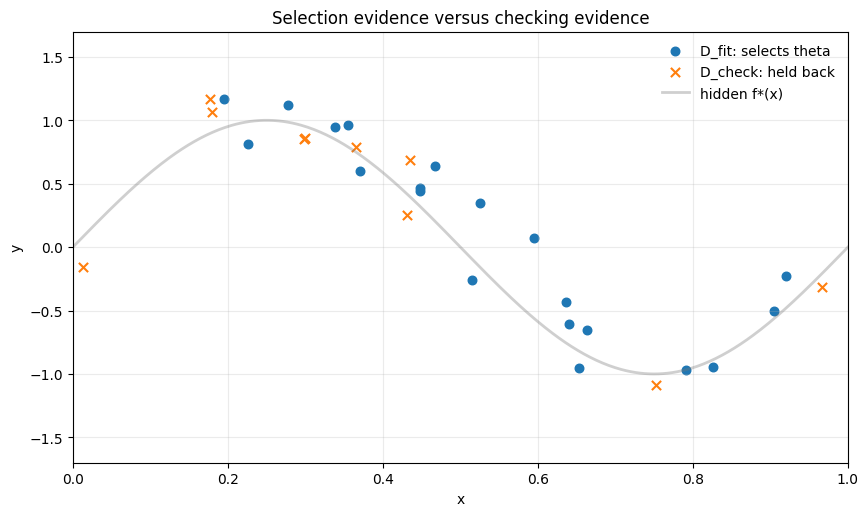

In [3]:
# See which points the optimizer can use and which points are held back.
x_grid = data.make_test_grid(n_points=500)
fig, ax = plt.subplots(figsize=(10.0, 5.6))
ax.scatter(x_train, y_train, s=38, color="#1f77b4", label="D_fit: selects theta")
ax.scatter(x_test, y_test, s=44, color="#ff7f0e", marker="x", label="D_check: held back")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
ax.set_title("Selection evidence versus checking evidence")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.7, 1.7)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


> **Predict before running.** The next cells keep the fitting rule fixed and vary polynomial degree. In workshop terms, that changes the hypothesis space $\mathcal{H}$ while the optimizer still uses $\mathcal{D}_{fit}$.
>
> Before running the comparison, predict which degree will have the lowest fit MSE, which degree will have the lowest check MSE, and which degree will look least defensible away from observed points. Name whether your prediction is mostly about $\mathcal{H}$, $\mathcal{D}$, or $\mathcal{O}$.


In [4]:
# Fit several degrees and compute the fit and check questions separately.
degrees_to_score = (0, 1, 3, 5, 7, 9, 15)
score_grid = data.make_test_grid(n_points=500)
score_rows = []
score_fits = {}

for degree in degrees_to_score:
    coeffs = models.fit_polynomial_mle(x_train, y_train, degree=degree)
    fit_pred = models.predict_polynomial(x_train, coeffs)
    check_pred = models.predict_polynomial(x_test, coeffs)
    score_fits[degree] = models.predict_polynomial(score_grid, coeffs)
    score_rows.append(
        {
            "degree": degree,
            "n_features": degree + 1,
            "fit_mse": metrics.mse(y_train, fit_pred),
            "check_mse": metrics.mse(y_test, check_pred),
            "coef_norm": metrics.coefficient_norm(coeffs),
        }
    )

best_fit = min(score_rows, key=lambda row: row["fit_mse"])
best_check = min(score_rows, key=lambda row: row["check_mse"])

print_rows(score_rows, digits=4, title="Fit and check error by hypothesis-space size")
print_rows(
    [
        {"criterion": "lowest_fit_mse", **best_fit},
        {"criterion": "lowest_check_mse", **best_check},
    ],
    digits=4,
    title="Different criteria can favour different selected models",
)


Fit and check error by hypothesis-space size
01. degree=0, n_features=1, fit_mse=0.5160, check_mse=0.5701, coef_norm=0.1017
02. degree=1, n_features=2, fit_mse=0.1277, check_mse=0.4476, coef_norm=3.4170
03. degree=3, n_features=4, fit_mse=0.0393, check_mse=0.1045, coef_norm=58.2102
04. degree=5, n_features=6, fit_mse=0.0350, check_mse=0.5772, coef_norm=208.7710
05. degree=7, n_features=8, fit_mse=0.0343, check_mse=33.3958, coef_norm=3.07e+04
06. degree=9, n_features=10, fit_mse=0.0283, check_mse=3116.0497, coef_norm=1.17e+06
07. degree=15, n_features=16, fit_mse=0.0160, check_mse=1.12e+10, coef_norm=7.12e+11
Different criteria can favour different selected models
01. criterion=lowest_fit_mse, degree=15, n_features=16, fit_mse=0.0160, check_mse=1.12e+10, coef_norm=7.12e+11
02. criterion=lowest_check_mse, degree=3, n_features=4, fit_mse=0.0393, check_mse=0.1045, coef_norm=58.2102


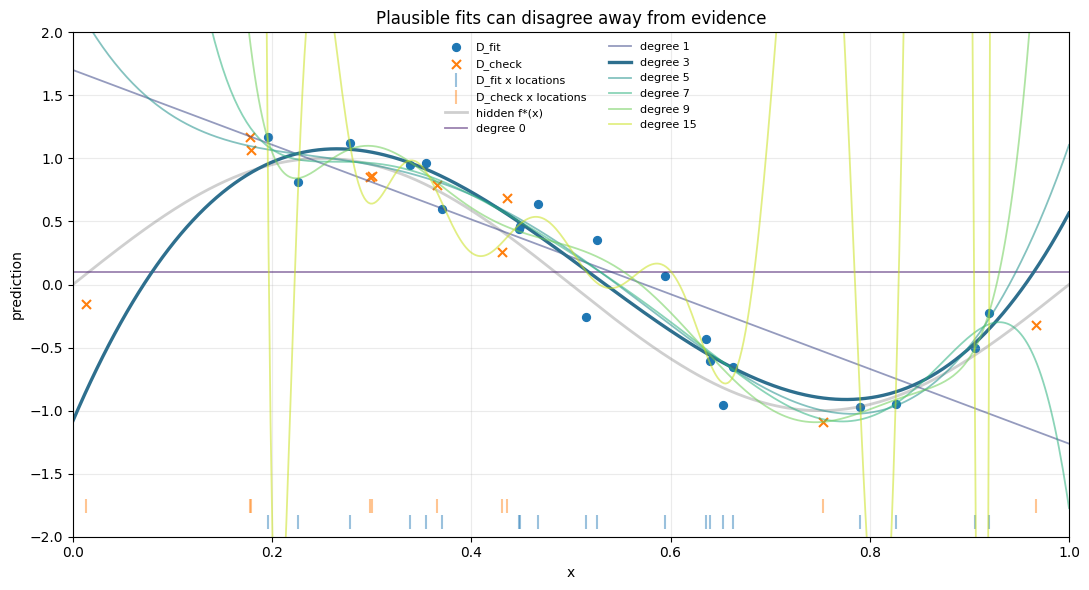

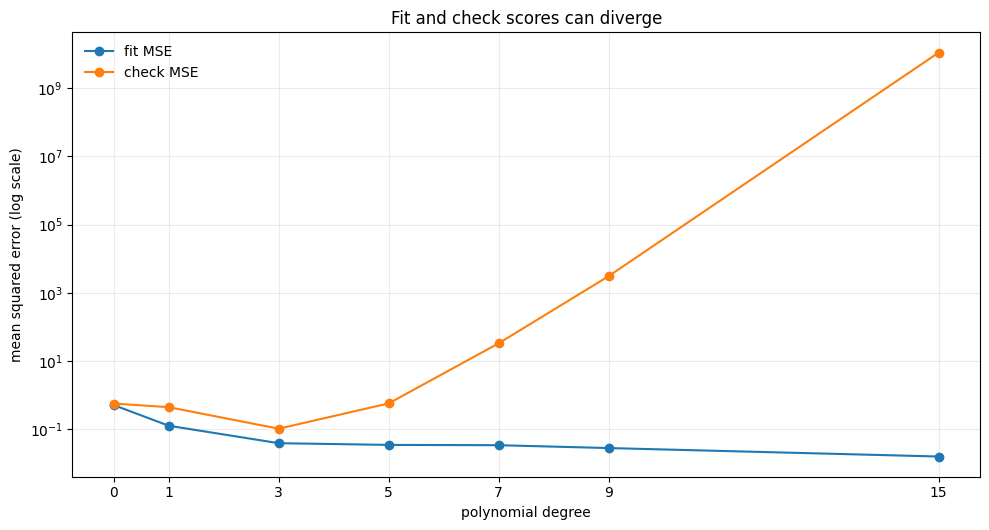

In [5]:
# Compare the selected curves and the score summaries.
degree_values = [row["degree"] for row in score_rows]
fit_mse_values = [row["fit_mse"] for row in score_rows]
check_mse_values = [row["check_mse"] for row in score_rows]

fig_curve, ax_curve = plt.subplots(figsize=(11.0, 6.0))

ax_curve.scatter(x_train, y_train, s=32, color="#1f77b4", label="D_fit")
ax_curve.scatter(x_test, y_test, s=42, color="#ff7f0e", marker="x", label="D_check")
ax_curve.scatter(x_train, np.full_like(x_train, -1.88), marker="|", s=90, color="#1f77b4", alpha=0.45, label="D_fit x locations")
ax_curve.scatter(x_test, np.full_like(x_test, -1.76), marker="|", s=90, color="#ff7f0e", alpha=0.45, label="D_check x locations")
ax_curve.plot(score_grid, data.true_function(score_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
colors = plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(degrees_to_score)))
for color, degree in zip(colors, degrees_to_score):
    linewidth = 2.4 if degree == best_check["degree"] else 1.3
    alpha = 1.0 if degree == best_check["degree"] else 0.55
    ax_curve.plot(score_grid, score_fits[degree], color=color, linewidth=linewidth, alpha=alpha, label=f"degree {degree}")
ax_curve.set_title("Plausible fits can disagree away from evidence")
ax_curve.set_xlabel("x")
ax_curve.set_ylabel("prediction")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-2.0, 2.0)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=8, ncol=2)
fig_curve.tight_layout()
show_fig(fig_curve)

fig_score, ax_score = plt.subplots(figsize=(10.0, 5.4))
ax_score.plot(degree_values, fit_mse_values, marker="o", label="fit MSE")
ax_score.plot(degree_values, check_mse_values, marker="o", label="check MSE")
ax_score.set_yscale("log")
ax_score.set_title("Fit and check scores can diverge")
ax_score.set_xlabel("polynomial degree")
ax_score.set_ylabel("mean squared error (log scale)")
ax_score.set_xticks(degree_values)
ax_score.grid(alpha=0.25, which="both")
ax_score.legend(frameon=False)
fig_score.tight_layout()
show_fig(fig_score)


### After running: diagnose overfitting as a travel problem

Compare fit error and check error.

- If fit error falls while check error worsens, the selected rule is becoming specialised to the evidence that selected it.
- If both errors are high, the hypothesis space or selection rule may be too limited for the pattern.
- If check error is low but local plots look weak in an important region, the average score may be hiding a support problem.

**Repack.** Generalisation asks whether the selected rule travels beyond the evidence used for selection.


**What the First Diagnostic Shows**

The first diagnostic used $\mathcal{D}_{fit}$ and $\mathcal{D}_{check}$ to show why selection evidence and checking evidence play different roles.

The fit split is allowed to choose parameters. For a fixed degree and fitting rule, it supplies the evidence used to construct $\hat{\theta}$. It can tell us which curve was selected from the current hypothesis space, but it cannot by itself tell us whether that selected curve will travel well.

The check split has a different job. It asks how the already-selected rule behaves on cases that did not select it. If we repeatedly use that check split to pick degrees, tune preprocessing, remove examples, or rewrite the workflow, it stops being an untouched check and becomes validation evidence.

The deployment region is different again. It names where the rule must be useful in the future. A low average check error is helpful, but it does not prove that every scientifically important region is covered. A rule can be selected cleanly and still be weak where the evidence is sparse, noisy, or outside the observed range.

In learning-frame language, the degree changes $\mathcal{H}$, the split changes which part of $\mathcal{D}$ is allowed to select, and least squares keeps $\mathcal{O}$ fixed. The plot is a warning: a rule can look defensible under one evidential role while remaining poorly supported under another.

## Turn Checking Into Validation and Test Discipline

The table may tempt you to choose the degree with the lowest held-out check error. That is a reasonable modelling impulse, but it changes what the held-out data are doing.

A held-out split has a clean interpretation only while it remains outside the decision process. If you inspect the check error once, use it to choose a degree, and then stop, it is acting as a simple validation signal. If you repeatedly use that same split to choose degree, change seeds, alter preprocessing, tune regularisation, or revise prompts, the split becomes part of the selection machinery. It still contains useful evidence, but it no longer gives the same clean final check on the whole workflow.

This is not a technicality. It changes what a score means. A validation score answers, "Which modelling choice looked best on this held-out evidence while we were making choices?" A test score should answer a stricter question: "After the modelling workflow was settled, how did the chosen workflow perform on evidence that did not steer it?" Mixing those roles can make performance look more stable than it really is.

> **Discuss.** What would happen in your own work if the same held-out cases were used both to choose the model and to claim final performance? Which decisions would have quietly learned from those cases?

So the simple $\mathcal{D}_{fit}$/$\mathcal{D}_{check}$ split becomes the more careful train/validation/test discipline:

- Training data select $\theta$ for a fixed modelling choice.
- Validation data guide modelling choices such as degree, regularisation, preprocessing, and prompts.
- Test data are saved for a final check after those choices have settled.

In notation, a fixed modelling choice $m$ might produce:

$$
\hat{\theta}_m = \mathcal{O}_m(\mathcal{D}_{train}).
$$

Validation compares several $m$ values. The final test score should probe the selected workflow as a whole, not keep steering it.

This still does not settle deployment. The remaining question is whether future cases come from similar, well-supported regions of $\Omega$.


### Validation versus test check

Check:

1. Which choices were influenced by validation evidence?
2. Which evidence remains available for a final test claim?
3. What would make the final test no longer final?

**Repack.** A validation score helps choose a workflow. A test score checks a settled workflow.


**Diagnose the Selection Pattern**

As the polynomial family becomes more flexible, fit error often falls. That is expected: a larger $\mathcal{H}$ gives the optimizer more ways to match $\mathcal{D}_{fit}$.

One way to write the selected parameter is:

$$
\hat{\theta} = \arg\min_{\theta \in \Theta} \mathcal{L}(\mathcal{D}_{fit}, \theta).
$$

The check observations ask how this selected $\hat{\theta}$ behaves on evidence that did not choose it. If fit error keeps improving while check error worsens, the selected rule has become too specialised to the selection evidence. That is the practical overfitting warning.

Before moving on, decide what would make a model choice defensible: the lowest validation score, a smoother-looking curve, a smaller coefficient warning sign, stronger coverage in the deployment region, or some combination of these.


## Ask Where the Rule Is Supported

Global held-out error is useful, but generalisation is local. A fitted rule is easier to trust in regions where the evidence resolves the behaviour we need, and harder to trust in gaps, sparse regions, high-noise regions, or extrapolation regions.

An overall score is like an average exam mark: it is useful for ranking, but weak for repair. If the average is disappointing, you still need to know which questions failed. In the same way, a global MSE tells us whether the model travelled well on average, while a support diagnostic asks where and why the rule is likely to fail.

This section shifts from model degree to evidence coverage.

### Reading the support formula

The formula below is not something to memorise. It gives mathematical support for a simple visual idea:

> Wide gaps and rapidly bending functions are harder to resolve from finite observations.

Use the formula to support the intuition, then return to the plot.

In one-dimensional interpolation, approximation error is often controlled by both spacing and curvature. For a simple linear interpolant $I_h f$ built from noiseless function values on intervals covered by interpolation nodes, a representative bound is:

$$
\lVert f - I_h f \rVert_\infty \leq \frac{h^2}{8}\max_x |f''(x)|.
$$

Here $h$ is the largest spacing between neighbouring nodes within the covered interval. The term $\max_x |f''(x)|$ measures how rapidly the function bends. Keep the intuition: where the function changes quickly, or where sample spacing is large, observations constrain the rule less tightly.

This bound belongs to a simple approximation setting. Dense interpolation support is not the same as statistical generalisation under noise; noise level, sampling bias, model choice, and the selection rule still matter.

A more general resolution diagnostic is the fill distance. Let $\mathcal{D}_x=\{x_i:(x_i,y_i)\in\mathcal{D}\}$ be the observed input locations. Then

$$
h_{\mathcal{D}_x}(\Omega) = \sup_{x \in \Omega}\min_{z \in \mathcal{D}_x}|x - z|.
$$

It asks: what is the farthest any point in the deployment region $\Omega$ can be from the nearest observed input? The answer depends on the chosen region and distance metric. In high-dimensional data, representation, scaling, and the curse of dimensionality all matter.

> **Discuss.** Before looking at the diagnostic, where would you be least willing to trust a fitted curve: a sparse region, a high-curvature region, or outside the observed range? What evidence would make you change your answer?

Read the next plot as a support diagnostic: where is evidence near, where is evidence absent, and where will deployment happen?

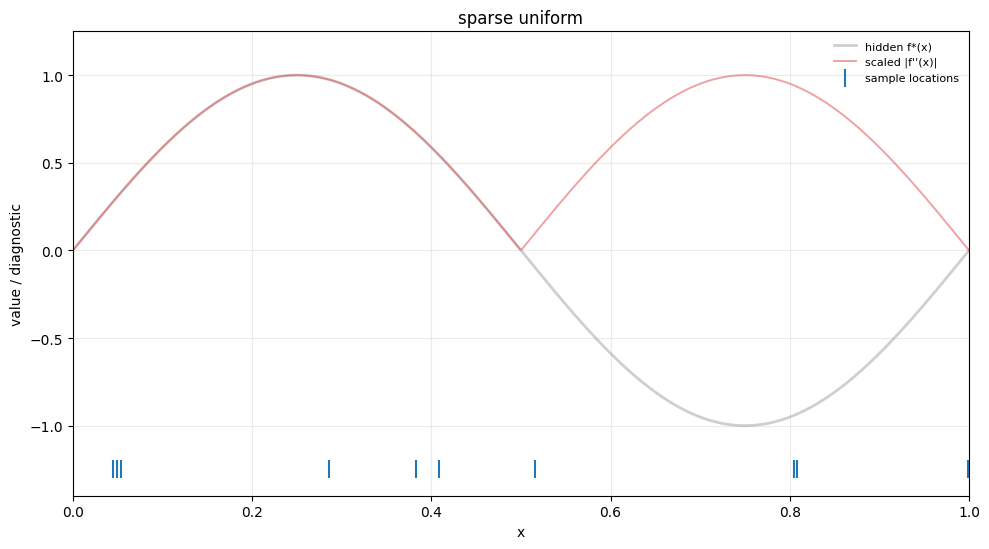

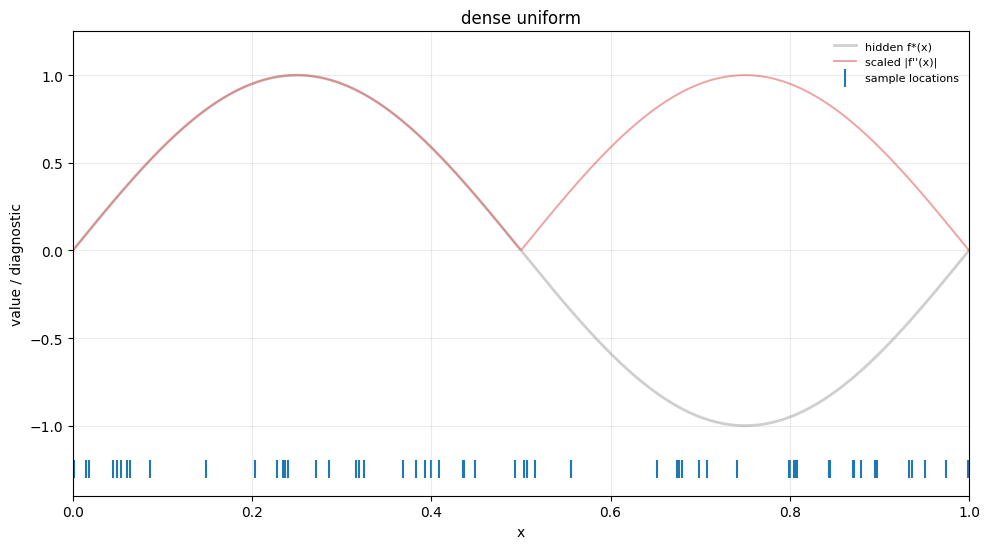

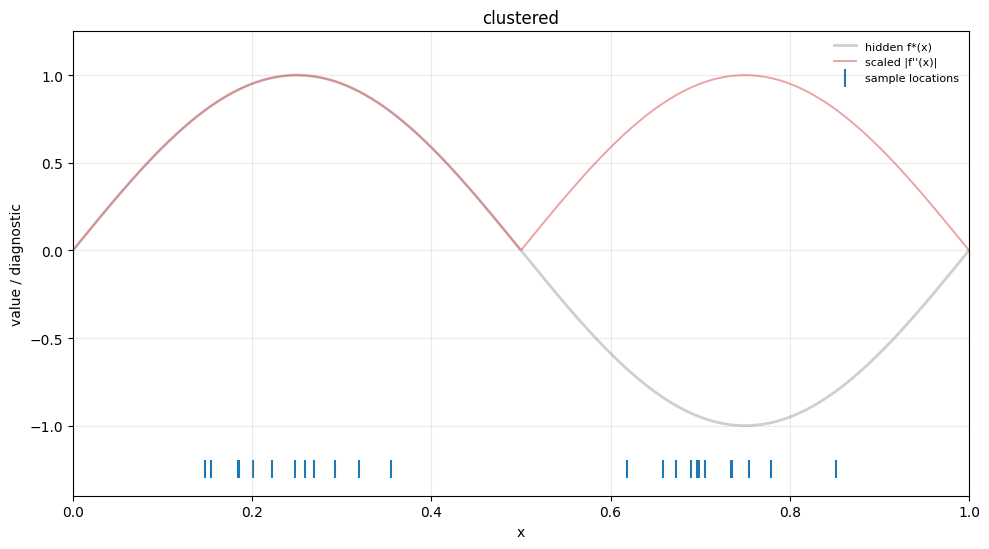

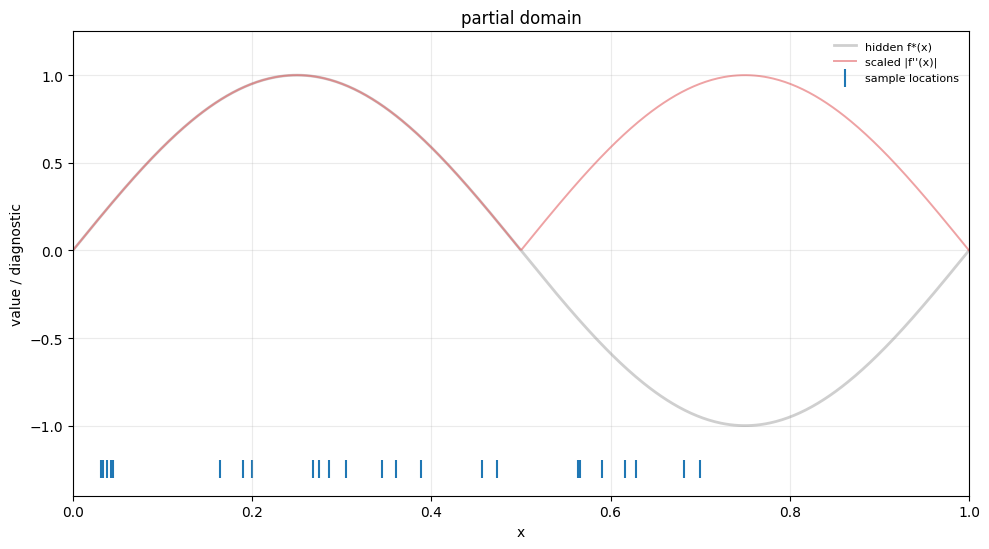

Resolution diagnostics
01. case=sparse uniform, n=10, largest_internal_gap=0.2897, fill_distance=0.1441, boundary_extrapolation=0.0453
02. case=dense uniform, n=60, largest_internal_gap=0.0962, fill_distance=0.0480, boundary_extrapolation=0.0012
03. case=clustered, n=24, largest_internal_gap=0.2643, fill_distance=0.1480, boundary_extrapolation=0.1480
04. case=partial domain, n=24, largest_internal_gap=0.1192, fill_distance=0.3006, boundary_extrapolation=0.3006


In [6]:
# Visualise sample spacing, fill distance, and function curvature as resolution diagnostics.
resolution_cases = [
    {"label": "sparse uniform", "n": 10, "sampling": "uniform", "seed": 5},
    {"label": "dense uniform", "n": 60, "sampling": "uniform", "seed": 5},
    {"label": "clustered", "n": 24, "sampling": "clustered", "seed": 5},
    {"label": "partial domain", "n": 24, "sampling": "partial_domain", "seed": 5},
]

x_grid = data.make_test_grid(n_points=600)
curvature = np.abs(-(2.0 * np.pi) ** 2 * np.sin(2.0 * np.pi * x_grid))
curvature_scaled = curvature / np.max(curvature)

resolution_rows = []

for settings in resolution_cases:
    x_res, y_res = data.make_regression_data(
        n=settings["n"],
        noise_std=0.0,
        seed=settings["seed"],
        sampling=settings["sampling"],
    )
    internal_gaps = np.diff(x_res)
    largest_internal_gap = float(np.max(internal_gaps)) if len(internal_gaps) else 0.0
    nearest_distances = np.min(np.abs(x_grid[:, None] - x_res[None, :]), axis=1)
    fill_distance = float(np.max(nearest_distances))
    boundary_extrapolation = float(max(x_res[0] - 0.0, 1.0 - x_res[-1]))
    resolution_rows.append(
        {
            "case": settings["label"],
            "n": settings["n"],
            "largest_internal_gap": largest_internal_gap,
            "fill_distance": fill_distance,
            "boundary_extrapolation": boundary_extrapolation,
        }
    )

    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
    ax.plot(x_grid, curvature_scaled, color="#e15759", alpha=0.55, linewidth=1.4, label="scaled |f''(x)|")
    ax.scatter(x_res, np.zeros_like(x_res) - 1.25, marker="|", s=170, color="#1f77b4", label="sample locations")
    ax.set_title(settings["label"])
    ax.set_xlabel("x")
    ax.set_ylabel("value / diagnostic")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-1.4, 1.25)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    show_fig(fig)

print_rows(resolution_rows, title="Resolution diagnostics")


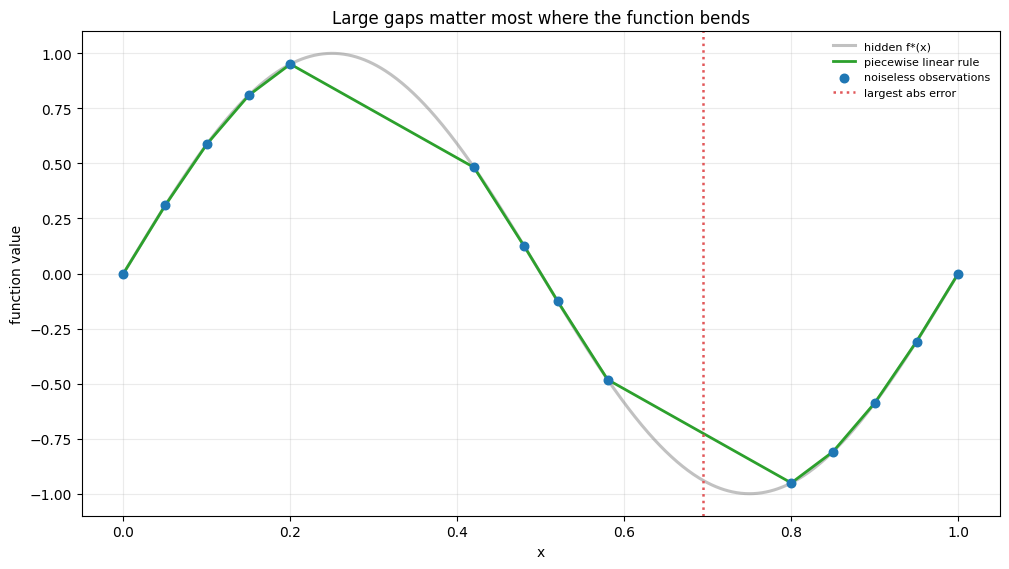

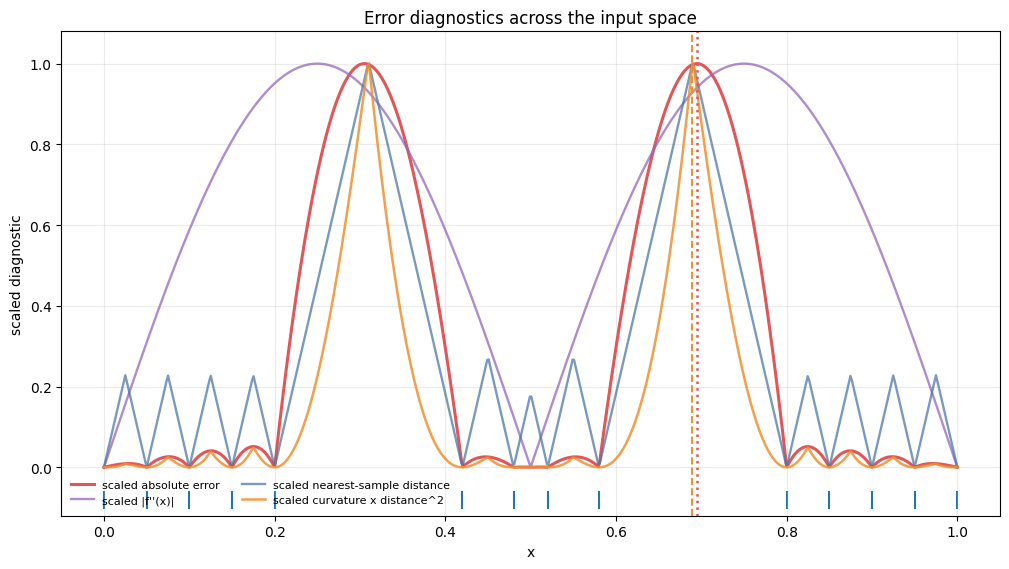

Curvature and spacing diagnostics for a simple interpolating rule
01. max_error_x=0.6945, abs_error=0.2138, nearest_sample_distance=0.1055, scaled_curvature_at_max_error=0.9398
02. max_risk_score_x=0.6895, risk_score=1.0000, abs_error_at_max_risk=0.2133, nearest_sample_distance=0.1095


In [7]:
# Relate interpolation error to curvature and local sample spacing in a controlled noiseless example.
x_support = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.42, 0.48, 0.52, 0.58, 0.80, 0.85, 0.90, 0.95, 1.00])
y_support = data.true_function(x_support)
y_true_grid = data.true_function(x_grid)
y_linear = np.interp(x_grid, x_support, y_support)
abs_error = np.abs(y_linear - y_true_grid)
nearest_support_distance = np.min(np.abs(x_grid[:, None] - x_support[None, :]), axis=1)

def scale01(values):
    max_value = float(np.max(values))
    if max_value == 0.0:
        return values
    return values / max_value

error_scaled = scale01(abs_error)
distance_scaled = scale01(nearest_support_distance)
risk_score = scale01(curvature * nearest_support_distance**2)
max_error_index = int(np.argmax(abs_error))
max_risk_index = int(np.argmax(risk_score))

fig_function, ax_function = plt.subplots(figsize=(10.2, 5.8))
ax_function.plot(x_grid, y_true_grid, color="#777777", alpha=0.45, linewidth=2.2, label="hidden f*(x)")
ax_function.plot(x_grid, y_linear, color="#2ca02c", linewidth=2.0, label="piecewise linear rule")
ax_function.scatter(x_support, y_support, s=38, color="#1f77b4", zorder=3, label="noiseless observations")
ax_function.axvline(x_grid[max_error_index], color="#e15759", linestyle=":", linewidth=1.8, label="largest abs error")
ax_function.set_title("Large gaps matter most where the function bends")
ax_function.set_xlabel("x")
ax_function.set_ylabel("function value")
ax_function.grid(alpha=0.25)
ax_function.legend(frameon=False, fontsize=8)
fig_function.tight_layout()
show_fig(fig_function)

fig_diag, ax_diag = plt.subplots(figsize=(10.2, 5.8))
ax_diag.plot(x_grid, error_scaled, color="#e15759", linewidth=2.2, label="scaled absolute error")
ax_diag.plot(x_grid, curvature_scaled, color="#9467bd", linewidth=1.7, alpha=0.75, label="scaled |f''(x)|")
ax_diag.plot(x_grid, distance_scaled, color="#4e79a7", linewidth=1.7, alpha=0.75, label="scaled nearest-sample distance")
ax_diag.plot(x_grid, risk_score, color="#f28e2b", linewidth=1.8, alpha=0.85, label="scaled curvature x distance^2")
ax_diag.scatter(x_support, np.zeros_like(x_support) - 0.08, marker="|", s=150, color="#1f77b4")
ax_diag.axvline(x_grid[max_error_index], color="#e15759", linestyle=":", linewidth=1.8)
ax_diag.axvline(x_grid[max_risk_index], color="#f28e2b", linestyle="--", linewidth=1.4)
ax_diag.set_title("Error diagnostics across the input space")
ax_diag.set_xlabel("x")
ax_diag.set_ylabel("scaled diagnostic")
ax_diag.set_ylim(-0.12, 1.08)
ax_diag.grid(alpha=0.25)
ax_diag.legend(frameon=False, fontsize=8, ncol=2)
fig_diag.tight_layout()
show_fig(fig_diag)

print_rows(
    [
        {
            "max_error_x": x_grid[max_error_index],
            "abs_error": abs_error[max_error_index],
            "nearest_sample_distance": nearest_support_distance[max_error_index],
            "scaled_curvature_at_max_error": curvature_scaled[max_error_index],
        },
        {
            "max_risk_score_x": x_grid[max_risk_index],
            "risk_score": risk_score[max_risk_index],
            "abs_error_at_max_risk": abs_error[max_risk_index],
            "nearest_sample_distance": nearest_support_distance[max_risk_index],
        },
    ],
    digits=4,
    title="Curvature and spacing diagnostics for a simple interpolating rule",
)


## Distinguish Gaps From Extrapolation

Weak support is not only about being outside the observed range. Some predictions are outside the smallest and largest observed inputs, but others sit inside the overall range while still lying in a sparse gap between clusters.

That middle case is easy to miss. A point can be between the smallest and largest observed $x$ values while still being weakly constrained by $\mathcal{D}$. A gap between clusters gives plausible fitted functions room to separate.

This matters for the generalisation argument. If a model performs poorly in a specific region, that failure is information: it tells us where the dataset weakly constrained $\hat{\theta}$ and where new measurements may be most valuable.

> **Predict before running.** In the next cell the degree and optimizer stay fixed. Which case should be more fragile near `probe_x = 0.78`: a gap inside the observed range, or a right-side deployment region with little support? Write down the failure pattern you expect before revealing the fitted curves.

In [8]:
# Compare a gap case with an extrapolation case, then probe a deployment region.
coverage_degree = 9
coverage_noise_std = 0.20
coverage_seed = 2026
probe_x = 0.78
deployment_region = (0.60, 0.90)
x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)

# Set to True after predicting where the fitted model should be fragile.
show_coverage_fit = False

coverage_cases = [
    {
        "case": "gap inside observed range",
        "sampling": "clustered",
        "find_internal_gap": True,
    },
    {
        "case": "right-side deployment",
        "sampling": "partial_domain",
        "find_internal_gap": False,
    },
]

coverage_results = []
coverage_rows = []
region_min, region_max = deployment_region
region_mask = (x_grid >= region_min) & (x_grid <= region_max)

for settings in coverage_cases:
    x_cov, y_cov = data.make_regression_data(
        n=26,
        noise_std=coverage_noise_std,
        seed=coverage_seed,
        sampling=settings["sampling"],
    )
    coeffs = models.fit_polynomial_mle(x_cov, y_cov, degree=coverage_degree)
    grid_pred = models.predict_polynomial(x_grid, coeffs)

    inside_observed_range = (x_grid >= np.min(x_cov)) & (x_grid <= np.max(x_cov))
    left_extrapolation = x_grid < np.min(x_cov)
    right_extrapolation = x_grid > np.max(x_cov)
    outside_range = left_extrapolation | right_extrapolation

    gap_mask = np.zeros_like(x_grid, dtype=bool)
    gap_bounds = None
    if settings["find_internal_gap"]:
        internal_gaps = np.diff(x_cov)
        gap_index = int(np.argmax(internal_gaps))
        gap_min = float(x_cov[gap_index])
        gap_max = float(x_cov[gap_index + 1])
        gap_bounds = (gap_min, gap_max)
        gap_mask = (x_grid >= gap_min) & (x_grid <= gap_max)

    local_support_mask = inside_observed_range & ~gap_mask
    region_nearest_distances = np.min(np.abs(x_grid[region_mask, None] - x_cov[None, :]), axis=1)
    probe_distance = float(np.min(np.abs(x_cov - probe_x)))
    probe_in_gap = bool(gap_bounds is not None and gap_bounds[0] <= probe_x <= gap_bounds[1])
    probe_in_range = bool(np.min(x_cov) <= probe_x <= np.max(x_cov))
    if probe_in_gap:
        probe_status = "inside largest gap"
    elif probe_in_range:
        probe_status = "inside observed range"
    else:
        probe_status = "outside observed range"

    def masked_mse(mask):
        if not np.any(mask):
            return np.nan
        return metrics.mse(y_grid_true[mask], grid_pred[mask])

    coverage_results.append(
        {
            "settings": settings,
            "x": x_cov,
            "y": y_cov,
            "grid_pred": grid_pred,
            "gap_mask": gap_mask,
            "gap_bounds": gap_bounds,
            "left_extrapolation": left_extrapolation,
            "right_extrapolation": right_extrapolation,
        }
    )
    coverage_rows.append(
        {
            "case": settings["case"],
            "x_min": np.min(x_cov),
            "x_max": np.max(x_cov),
            "largest_internal_gap": np.max(np.diff(x_cov)),
            "probe_x": probe_x,
            "probe_nearest_distance": probe_distance,
            "probe_status": probe_status,
            "region_fill_distance": np.max(region_nearest_distances),
            "train_mse": metrics.mse(y_cov, models.predict_polynomial(x_cov, coeffs)),
            "local_support_oracle_mse": masked_mse(local_support_mask),
            "deployment_region_oracle_mse": masked_mse(region_mask),
            "outside_range_oracle_mse": masked_mse(outside_range),
            "theta_norm_warning": metrics.coefficient_norm(coeffs),
        }
    )

print_rows(coverage_rows, digits=4, title="Probe support before deciding where to trust the fit")

Probe support before deciding where to trust the fit
01. case=gap inside observed range, x_min=0.1073, x_max=0.8677, largest_internal_gap=0.3061, probe_x=0.7800, probe_nearest_distance=0.0016, probe_status=inside observed range, region_fill_distance=0.0426, train_mse=0.0304, local_support_oracle_mse=0.0700, deployment_region_oracle_mse=0.0965, outside_range_oracle_mse=410.4587, theta_norm_warning=2.47e+06
02. case=right-side deployment, x_min=0.0090, x_max=0.6769, largest_internal_gap=0.1152, probe_x=0.7800, probe_nearest_distance=0.1031, probe_status=outside observed range, region_fill_distance=0.2229, train_mse=0.0323, local_support_oracle_mse=0.1732, deployment_region_oracle_mse=5415.0223, outside_range_oracle_mse=3.76e+05, theta_norm_warning=2.92e+06


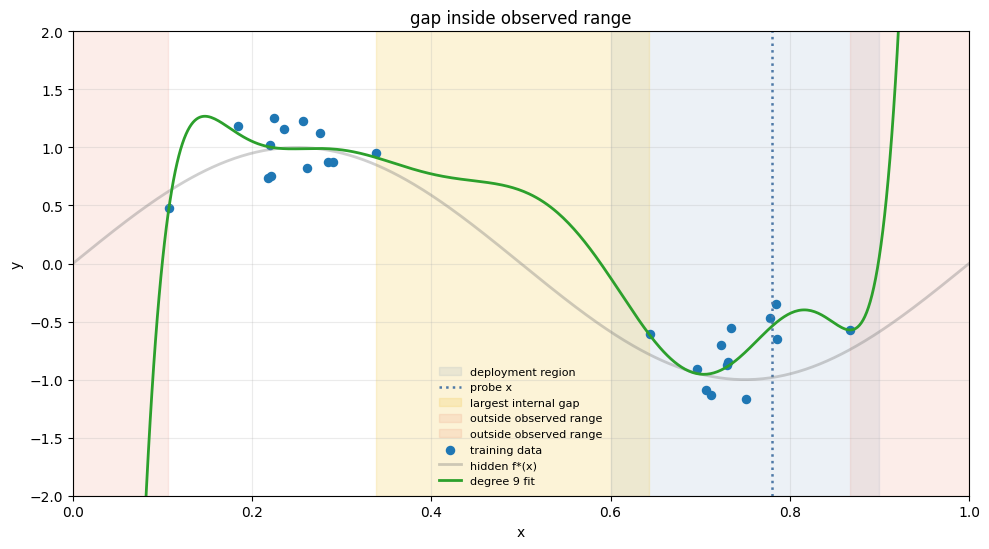

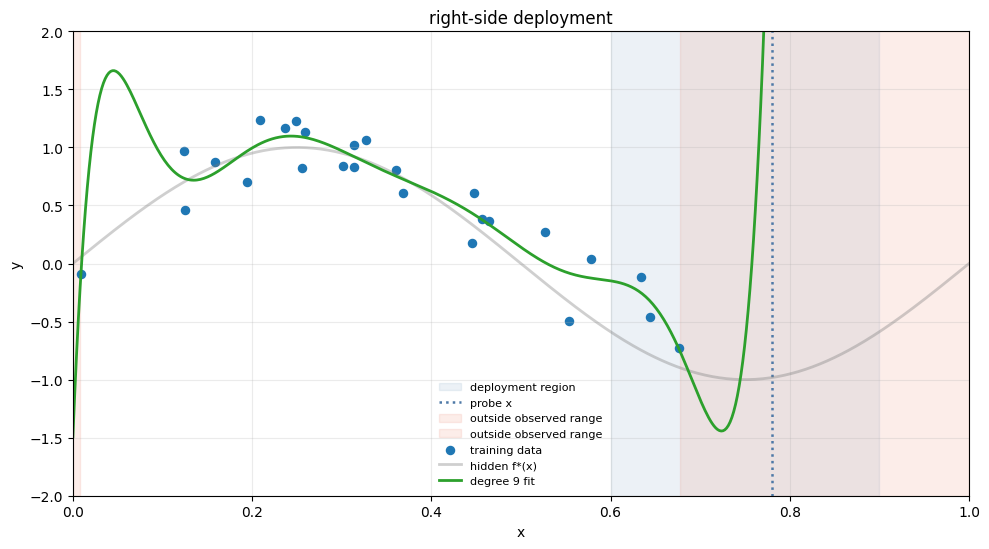

In [9]:
# Visualise where the fitted function is supported and where it is weakly constrained.
for result in coverage_results:
    settings = result["settings"]
    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.axvspan(region_min, region_max, color="#4e79a7", alpha=0.10, label="deployment region")
    ax.axvline(probe_x, color="#4e79a7", linestyle=":", linewidth=1.8, label="probe x")
    if np.any(result["gap_mask"]):
        gap_x = x_grid[result["gap_mask"]]
        ax.axvspan(gap_x.min(), gap_x.max(), color="#f2c94c", alpha=0.22, label="largest internal gap")
    if np.any(result["left_extrapolation"]):
        left_x = x_grid[result["left_extrapolation"]]
        ax.axvspan(left_x.min(), left_x.max(), color="#e76f51", alpha=0.12, label="outside observed range")
    if np.any(result["right_extrapolation"]):
        right_x = x_grid[result["right_extrapolation"]]
        ax.axvspan(right_x.min(), right_x.max(), color="#e76f51", alpha=0.12, label="outside observed range")
    ax.scatter(result["x"], result["y"], s=34, color="#1f77b4", label="training data")
    ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
    ax.plot(x_grid, result["grid_pred"], color="#2ca02c", linewidth=2.0, label=f"degree {coverage_degree} fit")
    ax.set_title(settings["case"])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-2.0, 2.0)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    show_fig(fig)


**Diagnose Local Support**

The shaded regions mark different ways evidence can be weak. Yellow marks the largest internal gap found from the sampled data itself. Red marks predictions outside the observed range. Blue marks a chosen deployment region $\Omega$, and the dotted line is a probe point you can change and rerun.

Read the summary by region, not just by average. A single global score can hide concentrated failure in the part of $\Omega$ that matters scientifically.

Before collecting more observations, discuss which evidence would change your mind most: points in the largest internal gap, points outside the current range, repeated measurements at existing points to estimate noise, or measurements targeted to the deployment region.

The oracle MSE columns compare predictions with the hidden function because this is a simulation. In real work, analogous diagnostics would come from targeted check measurements, held-out data from the relevant region, or domain-specific validation.


## Change the Data Space, Not the Model Class

Now keep the hypothesis space and fitting rule fixed, but change $\mathcal{D}$.

This mirrors the earlier notebooks: change one part of the learning frame while holding the others still. Here $\mathcal{H}$ and $\mathcal{O}$ stay fixed, while the data space changes through sample count, clustering, noise, and missing support.

If the selected function changes dramatically under a new data distribution, the diagnosis points toward evidence support. The sample may be thin, noisy, clustered, or missing in the region where predictions matter.

More rows help most when they improve the evidence relevant to $\Omega$. More observations in an already-supported region may leave the generalisation argument almost unchanged.

Before running the intervention cells, predict which case will have the worst deployment or grid error and why. Change one data-space feature at a time: sample count, clustering, noise, or support.


### Before running: predict data-space interventions

The next cells hold degree and fitting rule fixed while changing the data. Fill this table before running.

| Data intervention | Expected effect on support | Expected effect on error | Why? |
|---|---|---|---|
| More uniform data | | | |
| Clustered data | | | |
| Higher noise | | | |
| Partial domain | | | |



In [10]:
# Same fitting rule, different data spaces.
intervention_degree = 9
intervention_seed = 2026
interventions = [
    {"label": "uniform", "n": 20, "noise": 0.20, "sampling": "uniform"},
    {"label": "more data", "n": 80, "noise": 0.20, "sampling": "uniform"},
    {"label": "clustered", "n": 20, "noise": 0.20, "sampling": "clustered"},
    {"label": "partial domain", "n": 20, "noise": 0.20, "sampling": "partial_domain"},
]

x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)
intervention_results = []
intervention_rows = []

for settings in interventions:
    x_int, y_int = data.make_regression_data(
        n=settings["n"],
        noise_std=settings["noise"],
        seed=intervention_seed,
        sampling=settings["sampling"],
    )
    coeffs = models.fit_polynomial_mle(x_int, y_int, degree=intervention_degree)
    train_pred = models.predict_polynomial(x_int, coeffs)
    grid_pred = models.predict_polynomial(x_grid, coeffs)

    intervention_results.append(
        {
            "settings": settings,
            "x": x_int,
            "y": y_int,
            "grid_pred": grid_pred,
        }
    )
    intervention_rows.append(
        {
            "case": settings["label"],
            "n": settings["n"],
            "x_min": np.min(x_int),
            "x_max": np.max(x_int),
            "train_mse": metrics.mse(y_int, train_pred),
            "oracle_grid_mse": metrics.mse(y_grid_true, grid_pred),
            "coef_norm": metrics.coefficient_norm(coeffs),
        }
    )

print_rows(intervention_rows, digits=4, title="Predict which cases will be fragile before looking at the plots")


Predict which cases will be fragile before looking at the plots
01. case=uniform, n=20, x_min=0.1774, x_max=0.9670, train_mse=0.0171, oracle_grid_mse=181.4230, coef_norm=1.68e+06
02. case=more data, n=80, x_min=0.0018, x_max=0.9897, train_mse=0.0429, oracle_grid_mse=0.0030, coef_norm=2.19e+04
03. case=clustered, n=20, x_min=0.1073, x_max=0.7904, train_mse=0.0182, oracle_grid_mse=389.2530, coef_norm=6.18e+06
04. case=partial domain, n=20, x_min=0.1241, x_max=0.6769, train_mse=0.0171, oracle_grid_mse=3.84e+06, coef_norm=1.63e+07


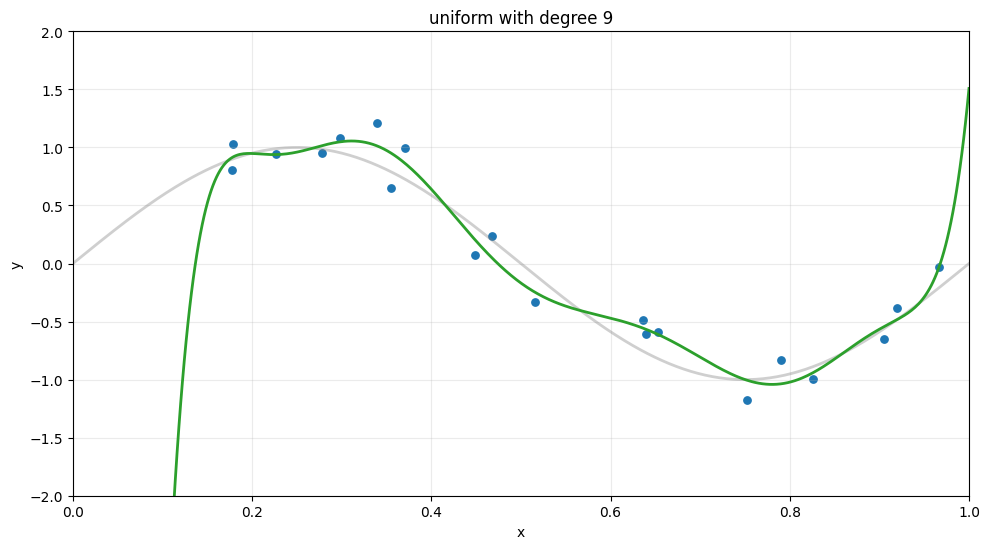

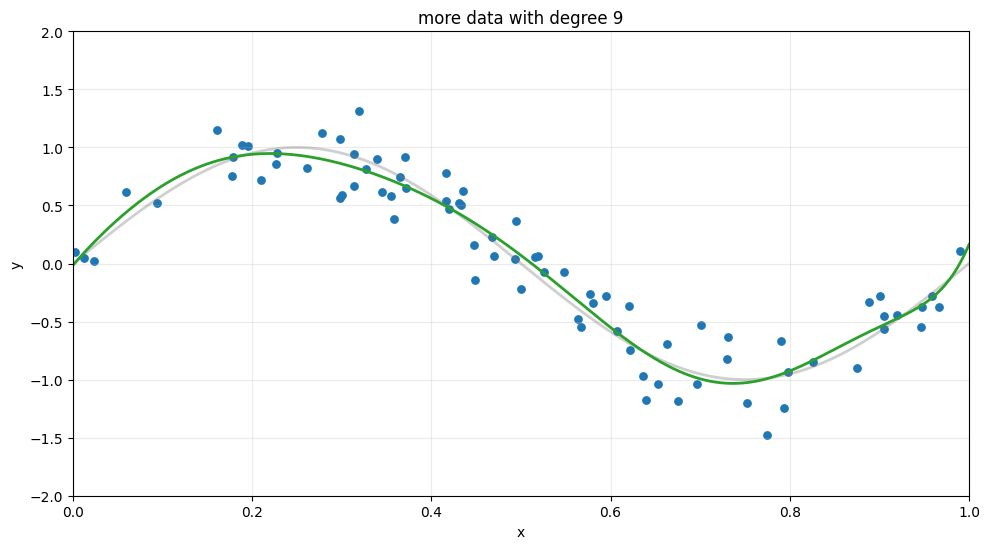

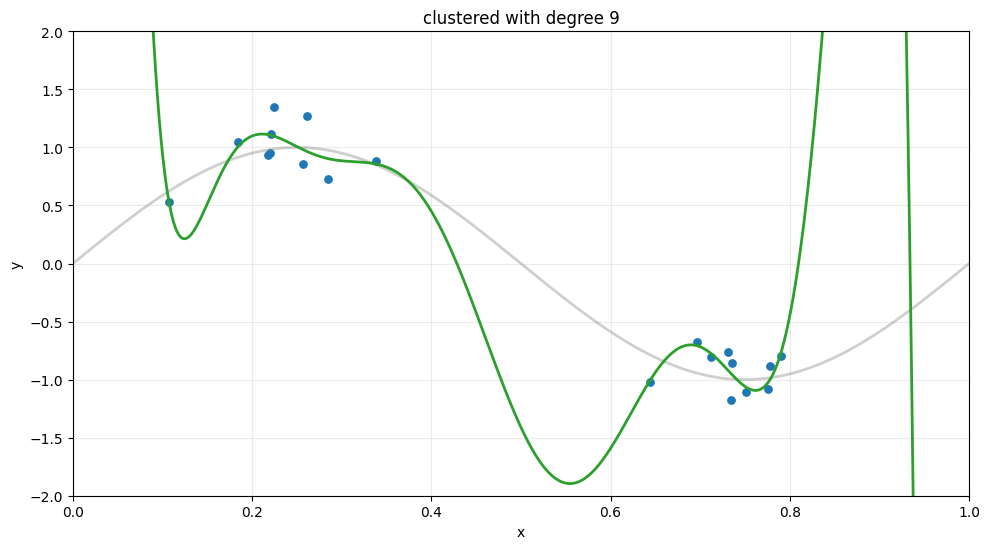

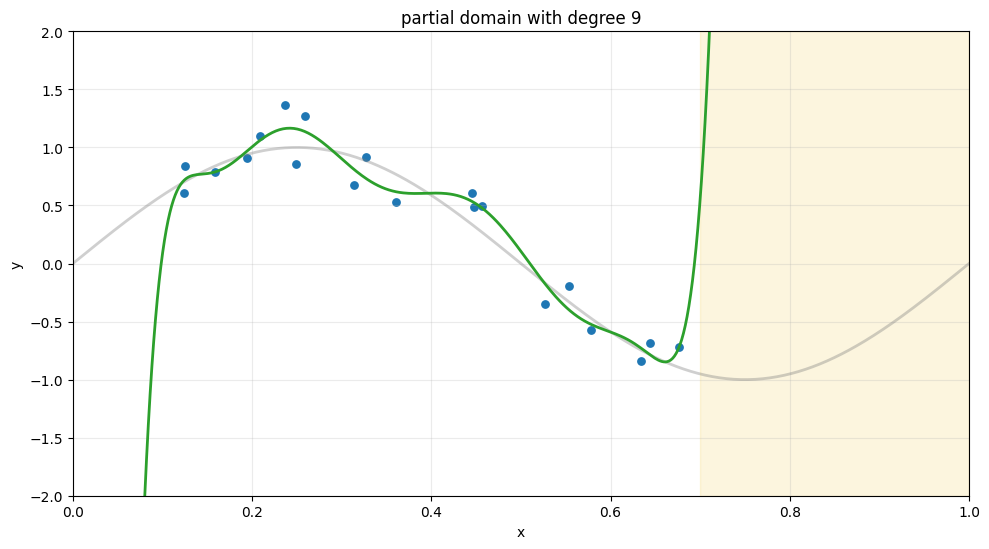

In [11]:
# Plot the same fitting rule under different data-space choices.
for result in intervention_results:
    settings = result["settings"]
    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.scatter(result["x"], result["y"], s=28, color="#1f77b4")
    ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.35, linewidth=2.0)
    ax.plot(x_grid, result["grid_pred"], color="#2ca02c", linewidth=2.0)
    if settings["sampling"] == "partial_domain":
        ax.axvspan(0.70, 1.00, color="#f2c94c", alpha=0.18)
    ax.set_title(f"{settings['label']} with degree {intervention_degree}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-2.0, 2.0)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    show_fig(fig)


**Diagnose the Data-Space Intervention**

More data helps most when it improves coverage of the region where predictions are needed. Clustered data can make the sample count look healthy while leaving blind spots. Partial-domain data can make a curve look reasonable where evidence exists and unstable where evidence is absent.

The `oracle_grid_mse` column is available because we know the simulated hidden function. The coefficient norm is only a warning sign here: in a monomial polynomial basis, large coefficients often travel with oscillation and poor conditioning, although the number itself depends on the chosen basis and scaling.

### Optional extension: larger AI systems

The same diagnostic habit can transfer to larger systems, but the core lesson here is traditional: weak data support produces weak generalisation claims.

For a larger AI system, a weak region might mean poor coverage of a task type, context pattern, document source, tool state, action sequence, or evaluation scenario. The same question still applies:

> What evidence supports this behaviour, and where is the system travelling on assumptions?

For scientists, model failure is information. It can tell us which region of the data geometry needs better measurement, denser sampling, cleaner labels, targeted evaluation, or a different hypothesis space. Generalisation work is therefore not just scorekeeping; it is a way to decide what evidence to collect next.

In $\mathcal{H}+\mathcal{D}+\mathcal{O}$ terms, this section kept degree and least squares fixed while changing the evidence. When the selected curve moved, the main diagnosis was data-space support, not a new optimizer.

> **Discuss.** If you had budget for ten new observations, where would you place them? Explain whether each choice is meant to reduce a gap, check extrapolation, estimate noise, or challenge the hypothesis space.

## Checkpoint: Make a Generalisation Argument

Fit several polynomial degrees, compare training and validation MSE, inspect the validation-only plot, and choose a degree you would defend as a scientific explanation.

Build the argument explicitly:

- What hypothesis space $\mathcal{H}$ did the chosen degree allow?
- What evidence did $\mathcal{D}_{train}$ use to select $\hat{\theta}$?
- What role did validation evidence play in selecting the modelling choice?
- Where is the selected rule supported or weakly supported in $\Omega$?
- Which result would change your mind?

Commit to a degree before running the final test cell. Write it down, then reveal the test MSE once as a final check. Did your validation-based choice transfer to the held-out test set?

After that, change `checkpoint_noise_std`, `checkpoint_n_samples`, or `checkpoint_sampling`. Does your argument still hold?

The aim is not to find a magic degree. The aim is to defend why a selected $s$ should, or should not, be treated as belonging to the acceptable solution space $\mathcal{S}$ for the intended use.


### Generalisation argument template

Before revealing the final test result, write your claim in this form:

> We selected [model/workflow] from [hypothesis space] using [training evidence] and [optimization rule]. We chose modelling settings using [validation evidence]. We will check the settled workflow on [test evidence]. We trust the selected rule in [deployment region] because [support/evaluation argument]. We would not trust it in [unsupported region] without [additional evidence].

This template is deliberately demanding. It forces the claim to name the model, data, optimization, evidence roles, and deployment region.


Checkpoint model choices using train and validation only
01. degree=0, train_mse=0.9117, validation_mse=0.5568, coef_norm_warning=0.1460
02. degree=1, train_mse=0.1309, validation_mse=0.1681, coef_norm_warning=4.7544
03. degree=3, train_mse=0.0247, validation_mse=0.0572, coef_norm_warning=91.7323
04. degree=5, train_mse=0.0238, validation_mse=0.0513, coef_norm_warning=608.4262
05. degree=9, train_mse=0.0163, validation_mse=41.4208, coef_norm_warning=7.12e+06
06. degree=15, train_mse=0.0036, validation_mse=2.49e+04, coef_norm_warning=1.51e+11
Validation-selected model
01. criterion=lowest_validation_mse, degree=5, train_mse=0.0238, validation_mse=0.0513, coef_norm_warning=608.4262
Commit to a degree now. Run the next cell only after the choice is written down.


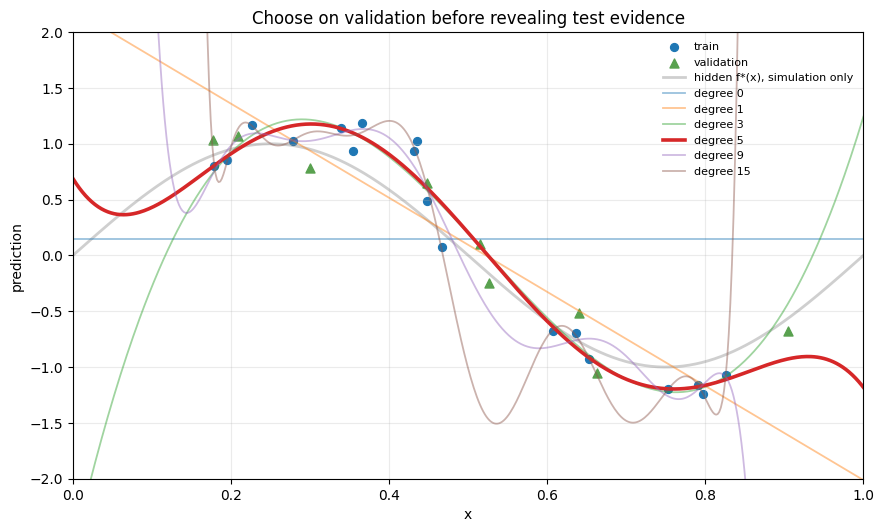

In [12]:
# Checkpoint working cell. Edit, rerun, and defend a model choice using train and validation only.
checkpoint_n_samples = 36
checkpoint_noise_std = 0.20
checkpoint_seed = 2026
checkpoint_sampling = "uniform"
checkpoint_degrees = (0, 1, 3, 5, 9, 15)

x_ckpt, y_ckpt = data.make_regression_data(
    n=checkpoint_n_samples,
    noise_std=checkpoint_noise_std,
    seed=checkpoint_seed,
    sampling=checkpoint_sampling,
)
x_build_ckpt, y_build_ckpt, x_test_ckpt, y_test_ckpt = data.train_test_split_for_workshop(
    x_ckpt,
    y_ckpt,
    test_size=0.25,
    seed=checkpoint_seed + 1,
)
x_train_ckpt, y_train_ckpt, x_val_ckpt, y_val_ckpt = data.train_test_split_for_workshop(
    x_build_ckpt,
    y_build_ckpt,
    test_size=0.33,
    seed=checkpoint_seed + 2,
)

checkpoint_rows = []
checkpoint_fits = {}
checkpoint_coeffs = {}
x_grid = data.make_test_grid(n_points=500)
for degree in checkpoint_degrees:
    coeffs = models.fit_polynomial_mle(x_train_ckpt, y_train_ckpt, degree=degree)
    train_pred = models.predict_polynomial(x_train_ckpt, coeffs)
    val_pred = models.predict_polynomial(x_val_ckpt, coeffs)
    checkpoint_coeffs[degree] = coeffs
    checkpoint_fits[degree] = models.predict_polynomial(x_grid, coeffs)
    checkpoint_rows.append(
        {
            "degree": degree,
            "train_mse": metrics.mse(y_train_ckpt, train_pred),
            "validation_mse": metrics.mse(y_val_ckpt, val_pred),
            "coef_norm_warning": metrics.coefficient_norm(coeffs),
        }
    )

best_validation = min(checkpoint_rows, key=lambda row: row["validation_mse"])
selected_degree = int(best_validation["degree"])

print_rows(checkpoint_rows, digits=4, title="Checkpoint model choices using train and validation only")
print_rows([{"criterion": "lowest_validation_mse", **best_validation}], digits=4, title="Validation-selected model")
print("Commit to a degree now. Run the next cell only after the choice is written down.")

fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.scatter(x_train_ckpt, y_train_ckpt, s=32, color="#1f77b4", label="train")
ax.scatter(x_val_ckpt, y_val_ckpt, s=42, marker="^", color="#59a14f", label="validation")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x), simulation only")
for degree in checkpoint_degrees:
    linewidth = 2.6 if degree == selected_degree else 1.3
    alpha = 1.0 if degree == selected_degree else 0.45
    ax.plot(x_grid, checkpoint_fits[degree], linewidth=linewidth, alpha=alpha, label=f"degree {degree}")
ax.set_title("Choose on validation before revealing test evidence")
ax.set_xlabel("x")
ax.set_ylabel("prediction")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
show_fig(fig)


**Final Test Reveal**

Run the next cell only after the model choice has been written down. This cell uses the untouched test split for the validation-selected degree and should not be used to keep tuning the workflow.


Final test check for the validation-selected model only
01. selected_degree=5, validation_mse=0.0513, test_mse_final_check=0.2323


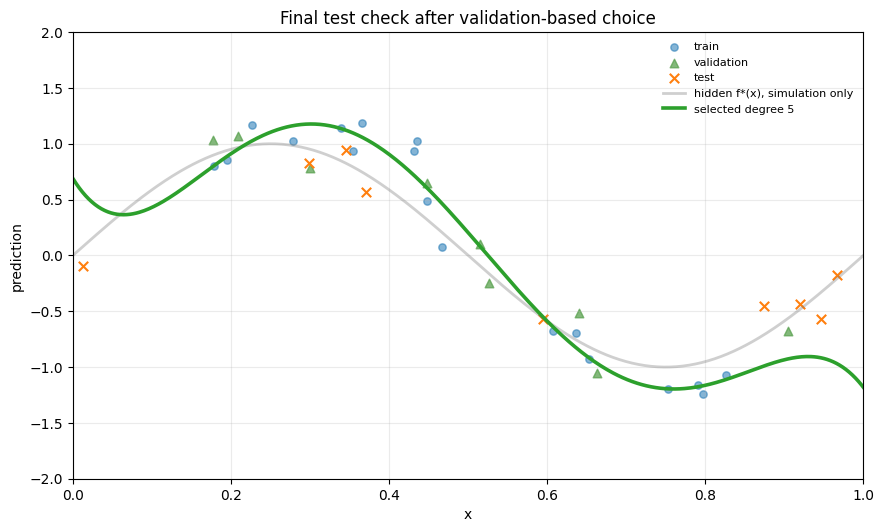

In [13]:
# Final test check. Run once after committing to a degree.
selected_test_pred = models.predict_polynomial(x_test_ckpt, checkpoint_coeffs[selected_degree])
selected_test_mse = metrics.mse(y_test_ckpt, selected_test_pred)

print_rows(
    [
        {
            "selected_degree": selected_degree,
            "validation_mse": best_validation["validation_mse"],
            "test_mse_final_check": selected_test_mse,
        }
    ],
    digits=4,
    title="Final test check for the validation-selected model only",
)

fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.scatter(x_train_ckpt, y_train_ckpt, s=28, color="#1f77b4", alpha=0.55, label="train")
ax.scatter(x_val_ckpt, y_val_ckpt, s=38, marker="^", color="#59a14f", alpha=0.75, label="validation")
ax.scatter(x_test_ckpt, y_test_ckpt, s=46, marker="x", color="#ff7f0e", label="test")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x), simulation only")
ax.plot(x_grid, checkpoint_fits[selected_degree], color="#2ca02c", linewidth=2.6, label=f"selected degree {selected_degree}")
ax.set_title("Final test check after validation-based choice")
ax.set_xlabel("x")
ax.set_ylabel("prediction")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
show_fig(fig)


## Summary: Generalisation as a Defensibility Argument

Notebook 03 answered: given $\mathcal{H}$, $\mathcal{D}$, and $\mathcal{O}$, which solution did the machinery select?

Notebook 04 answered a different question: where is that selected solution defensible?

1. **Selection evidence is not checking evidence.** The same data cannot both freely guide model choice and provide an untouched final check. Once a held-out split steers choices, it is acting as validation evidence.

2. **Support is local.** A model can be well constrained near dense observations and weakly constrained in gaps, sparse regions, noisy regions, or outside the observed range. A global score can hide regional failure.

3. **Overfitting is a travel problem.** A rule can explain the data that selected it while failing to carry stable structure to held-out cases. Held-out performance is useful because it asks whether the selected rule travels beyond the evidence used for selection.

4. **Model choice is an argument.** A strong argument names the hypothesis space $\mathcal{H}$, the evidence $\mathcal{D}$, the optimization space $\mathcal{O}$, the target deployment region $\Omega$, and the diagnostics that would change the decision.

The compact conclusion is:

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s \quad \text{does not by itself prove} \quad s\in\mathcal{S}.
$$

Generalisation is the extra evidential argument that the selected rule is acceptable for the region and use we care about.

## Evaluation Discipline Beyond This Notebook

Train, validation, and test splits are not paperwork. They protect different parts of the argument.

The training set is selection evidence for parameters. It shapes the fitted rule directly: coefficients, weights, embeddings, prompts, thresholds, retrieval settings, or any other configurable part of the system. Good training performance tells us the workflow can explain the evidence it was allowed to use.

The validation set is selection evidence for choices around the model. It can guide degree, regularisation strength, feature design, early stopping, prompt wording, retrieval configuration, tool policy, or data-cleaning decisions. That is useful, but it means the validation set is no longer an independent final check. It has influenced the workflow.

The test set is reserved for the settled workflow. It should answer: after all ordinary modelling choices are fixed, how does the chosen system behave on evidence that did not shape those choices? If the test result triggers another round of tuning, the test set has effectively become validation evidence. A new final check is then needed.

Data leakage breaks this separation. Leakage can be obvious, such as training on test labels, or subtle, such as normalising with statistics computed over the full dataset, deduplicating after the split, repeatedly inspecting test failures, selecting examples because they improve a benchmark, or letting near-duplicate records appear across splits. In time-dependent, user-dependent, or location-dependent data, leakage can also happen when random splits mix future information, the same user, or the same scenario across train and test.

For larger ML systems and LLM systems, the unit being evaluated is the whole workflow, not only the model weights. The workflow may include retrieval, prompts, tools, post-processing, human review, safety filters, caching, and fallback policies. A benchmark becomes validation evidence once it is used to steer these choices. A final evaluation should therefore be fresh enough, representative enough, and separated enough to tell us how the settled system behaves in the intended deployment region.

The practical discipline is simple to state and hard to maintain: decide which evidence is allowed to shape the system, which evidence is allowed to compare candidate systems, and which evidence is held back for the final claim. Then report the claim in that language. A defensible generalisation statement is not just "the score was good"; it is "this settled workflow was checked on this kind of untouched evidence for this intended region of use."

> **Discuss.** Think of a model, LLM workflow, or scientific analysis you have seen. What would count as training evidence, validation evidence, and final test evidence? Where could leakage enter without anyone noticing?

## Final reusable diagnostic

For any fitted model, ask:

| Question | Diagnostic role |
|---|---|
| What was the hypothesis space? | Names what could be represented. |
| What data selected the parameters? | Names the evidence that shaped the solution. |
| What optimization rule selected the solution? | Names the loss, penalty, and solver. |
| What validation evidence shaped modelling choices? | Names what guided tuning. |
| What test evidence remained untouched? | Names the final check. |
| Where is the deployment region $\Omega$? | Names where the model must work. |
| Where is the model weakly supported? | Names where not to trust the result without more evidence. |

**Final takeaway.** A model is not defensible because it has one good score. It is defensible when the hypothesis space, data evidence, optimization rule, and deployment region support the claim being made.


## Optional Extension: Bridge to Notebook 05

The core Workshop 1 arc is now complete. We have inspected the evidence $\mathcal{D}$, the hypothesis space $\mathcal{H}$, the selection machinery $\mathcal{O}$, and the question of whether the selected solution belongs in the acceptable solution space $\mathcal{S}$ for future use.

Notebook 05 is optional. It does not replace the earlier diagnosis; it gives parts of it a probabilistic interpretation. A likelihood says what measurement story would make the observed residuals plausible. A prior says which hypotheses or parameters were plausible before this dataset arrived. Evidence and posterior uncertainty then become additional ways to ask whether the selected or summarised solution is defensible.


## References

A compact set of checked references for validation, generalisation diagnostics, interpolation error, data coverage, and active data collection.

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). [*The Elements of Statistical Learning: Data Mining, Inference, and Prediction*](https://link.springer.com/book/10.1007/978-0-387-84858-7), 2nd ed. Model assessment, validation, test error, and model-complexity trade-offs.
- Stone, M. (1974). [*Cross-Validatory Choice and Assessment of Statistical Predictions*](https://academic.oup.com/jrsssb/article/36/2/111/7027414), *Journal of the Royal Statistical Society: Series B*, 36(2), 111-133. Classical support for using held-out evidence in model choice and assessment.
- Süli, E., & Mayers, D. F. (2003). [*An Introduction to Numerical Analysis*](https://www.cambridge.org/core/books/an-introduction-to-numerical-analysis/FD8BCAD7FE68002E2179DFF68B8B7237/listing). Interpolation error and the role of sample spacing and curvature in simple approximation settings.
- Wendland, H. (2004). [*Scattered Data Approximation*](https://www.cambridge.org/core/product/identifier/9780511617539/type/book). Fill distance, scattered-data geometry, and approximation error controlled by data coverage.
- Settles, B. (2009). [*Active Learning Literature Survey*](https://minds.wisconsin.edu/handle/1793/60660), Computer Sciences Technical Report 1648, University of Wisconsin-Madison. Turning model diagnostics into targeted data-collection questions.


## 📝 Generalisation Diagnostic Lessons Summary

This notebook focused on the final question of the learning problem: **When should the selected solution be trusted?**

1.  **Fit $\neq$ Generalisation**: Winning the training objective (lowest MSE on $\mathcal{D}_{fit}$) is not the same as being a good model. High-degree models can achieve near-zero training error while failing catastrophically on new data.
2.  **The Role of $\mathcal{D}_{check}$**: We use held-out evidence to detect when a selector has chosen a solution that is too fragile. This "check" evidence constrains our trust, even if it didn't participate in the optimization.
3.  **Data Support & Fill Distance**: A model's reliability is tied to the "geometry" of the training data. Large internal gaps (sparse data) or regions outside the observed range (extrapolation) are high-risk areas where the model is unconstrained by evidence.
4.  **Trust Boundaries**: We must distinguish between **interpolation** (predicting between observed points) and **extrapolation** (predicting outside the observed range). Most models are only defensible within the "convex hull" of the training data.
5.  **Complexity vs. Evidence**: Generalisation requires a balance between the flexibility of $\mathcal{H}$, the strength of $\mathcal{O}$ (regularisation), and the density of $\mathcal{D}$. If the model has "room to wiggle" where there is no data, it will likely fail.

**Takeaway**: Generalisation is not a property of the model alone, but a relationship between the model's flexibility and the evidence that constrains it.
